In [1]:
import warnings
warnings.filterwarnings("ignore", category = UserWarning)

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from utils import *
from cifar_dla import *
from mnist_cnn import *

import os
import glob

### 1. MNIST 베이스 모델 학습

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(), # PyTorch 텐서로 변환
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 평균 0.1307, 표준편차 0.3081로 정규화
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

val_ratio = 0.2
val_size = int(len(train_dataset) * val_ratio)
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator = torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size = 1000, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"훈련 데이터 개수: {len(train_subset)}")
print(f"검증 데이터 개수: {len(val_subset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

훈련 데이터 개수: 48000
검증 데이터 개수: 12000
테스트 데이터 개수: 10000


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = MNIST_CNN().to(device)
print(cnn)

MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Epoch 1/5:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 750/750 [00:09<00:00, 83.13it/s, loss=0.1566] 


 Val Accuracy: 0.9823     ✅ Best model saved (acc: 0.9823)


Epoch 2/5: 100%|██████████| 750/750 [00:09<00:00, 80.64it/s, loss=0.0455] 


 Val Accuracy: 0.9849     ✅ Best model saved (acc: 0.9849)


...

 Val Accuracy: 0.9869     ✅ Best model saved (acc: 0.9869)


Epoch 4/5: 100%|██████████| 750/750 [00:09<00:00, 81.64it/s, loss=0.0220] 


 Val Accuracy: 0.9905     ✅ Best model saved (acc: 0.9905)


Epoch 5/5: 100%|██████████| 750/750 [00:08<00:00, 83.38it/s, loss=0.0164] 


 Val Accuracy: 0.9872

Training completed. Best Val Acc: 0.9905


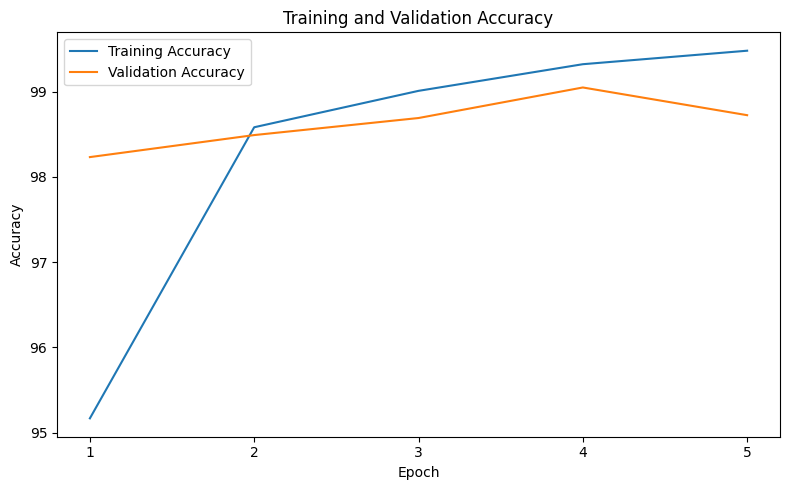

In [5]:
cnn, history = train_model(cnn, train_loader, val_loader, epochs = 5, mode = "mnist")
plot_accuracy(history, mode = "mnist_cnn")

In [7]:
cnn = MNIST_CNN()

files = glob.glob("./training_result/mnist*.pt")
latest_file = max(files, key = lambda x: os.path.basename(x).replace("mnist_", ""))
print(f"Latest file: {latest_file}")

cnn.load_state_dict(torch.load(latest_file, map_location = device))
test_acc = evaluate_model(cnn, test_loader, device = device)

print("Test accuracy: ", test_acc)

Latest file: ./training_result/mnist_202603291242.pt
Test accuracy:  0.9917


### 2. CIFAR-10 모델 학습 (DLA)

In [8]:
# 데이터셋 로드

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean = (0.4914, 0.4822, 0.4465), # RGB 채널별 평균
        std = (0.2470, 0.2435, 0.2616) # RGB 채널별 표준편차
    )
])

train_dataset = datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform)
test_dataset = datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)

val_size = int(len(train_dataset) * 0.2)
train_size = len(train_dataset) - val_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator = torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_subset, batch_size = 1000, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 1000, shuffle = False)

print(f"훈련 데이터 개수: {len(train_subset)}")
print(f"검증 데이터 개수: {len(val_subset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

훈련 데이터 개수: 40000
검증 데이터 개수: 10000
테스트 데이터 개수: 10000


Epoch 1/20: 100%|██████████| 625/625 [04:18<00:00,  2.42it/s, loss=1.4729]


 Val Accuracy: 0.5613     ✅ Best model saved (acc: 0.5613)


Epoch 2/20: 100%|██████████| 625/625 [04:14<00:00,  2.46it/s, loss=1.0361]


 Val Accuracy: 0.6630     ✅ Best model saved (acc: 0.6630)


Epoch 3/20: 100%|██████████| 625/625 [04:14<00:00,  2.46it/s, loss=0.8403]


...

 Val Accuracy: 0.7988


Epoch 19/20: 100%|██████████| 625/625 [04:17<00:00,  2.43it/s, loss=0.0618]


 Val Accuracy: 0.8134     ✅ Best model saved (acc: 0.8134)


Epoch 20/20: 100%|██████████| 625/625 [04:19<00:00,  2.40it/s, loss=0.0512]


 Val Accuracy: 0.8159     ✅ Best model saved (acc: 0.8159)

Training completed. Best Val Acc: 0.8159


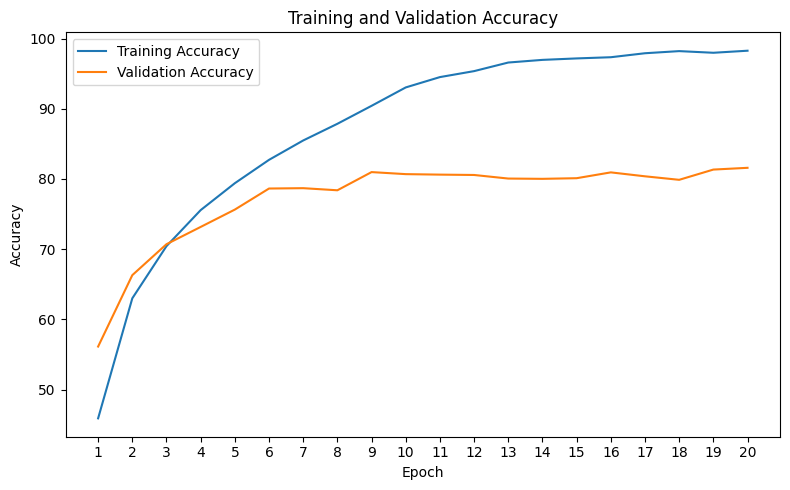

In [9]:
dla = SimpleDLA().to(device)

dla.train()
dla, history = train_model(dla, train_loader, val_loader, epochs = 20, device = device, mode = "cifar_dla")
plot_accuracy(history, mode = "cifar_dla")

In [10]:
dla = SimpleDLA()

files = glob.glob("./training_result/cifar_dla*.pt")
latest_file = max(files, key = lambda x: os.path.basename(x).replace("cifar_dla_", ""))
print(f"Latest file: {latest_file}")

dla.load_state_dict(torch.load(latest_file, map_location = device))
evaluate_model(dla, test_loader, device = device)

Latest file: ./training_result/cifar_dla_202603291243.pt


0.8033

### CIFAR-10 모델 학습 (ResNet18, Pre-trained + Fine-tuning)

In [11]:
import resnet18
from utils import *

In [12]:
# 데이터셋 로드

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean = (0.4914, 0.4822, 0.4465), # RGB 채널별 평균
        std = (0.2470, 0.2435, 0.2616) # RGB 채널별 표준편차
    )
])

train_dataset = datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform)
test_dataset = datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)

val_size = int(len(train_dataset) * 0.2)
train_size = len(train_dataset) - val_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator = torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_subset, batch_size = 1000, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 1000, shuffle = False)

print(f"훈련 데이터 개수: {len(train_subset)}")
print(f"검증 데이터 개수: {len(val_subset)}")
print(f"테스트 데이터 개수: {len(test_dataset)}")

훈련 데이터 개수: 40000
검증 데이터 개수: 10000
테스트 데이터 개수: 10000


In [13]:
resnet = resnet18.ResNet18(freeze_backbone= False)

# 학습 대상 파라미터 확인
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())

print(f"학습 파라미터: {trainable:,}")
print(f"전체 파라미터: {total:,}")

학습 파라미터: 11,173,962
전체 파라미터: 11,173,962


In [14]:
print(resnet)

ResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv

Epoch 1/20:  11%|█         | 68/625 [00:16<02:14,  4.16it/s, loss=0.1653]

Epoch 1/20: 100%|██████████| 625/625 [02:32<00:00,  4.10it/s, loss=0.7444]


 Val Accuracy: 0.8548     ✅ Best model saved (acc: 0.8548)


Epoch 2/20: 100%|██████████| 625/625 [02:31<00:00,  4.11it/s, loss=0.2805]


 Val Accuracy: 0.8777     ✅ Best model saved (acc: 0.8777)


...

 Val Accuracy: 0.8937


Epoch 19/20: 100%|██████████| 625/625 [02:32<00:00,  4.11it/s, loss=0.0164]


 Val Accuracy: 0.8999


Epoch 20/20: 100%|██████████| 625/625 [02:32<00:00,  4.11it/s, loss=0.0175]


 Val Accuracy: 0.8969

Training completed. Best Val Acc: 0.9035


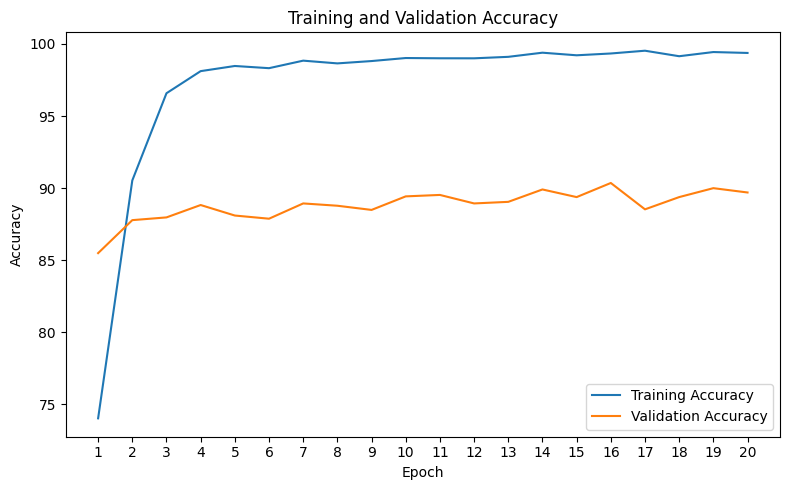

In [15]:
resnet, history = train_model(
    model = resnet,
    train_loader = train_loader,
    val_loader = val_loader,
    epochs = 20,
    lr = 1e-4,
    mode = "cifar_resnet18_finetune",
)

plot_accuracy(history, mode = "cifar_resnet18")

In [16]:
resnet = resnet18.ResNet18()

files = glob.glob("./training_result/cifar_resnet18_finetune*.pt")
latest_file = max(files, key = lambda x: os.path.basename(x).replace("cifar_resnet18_finetune_", ""))
print(f"Latest file: {latest_file}")

resnet.load_state_dict(torch.load(latest_file, map_location = device))
test_acc = evaluate_model(resnet, test_loader, device = device)

print("Test accuracy: ", test_acc)

Latest file: ./training_result/cifar_resnet18_finetune_202603291419.pt
Test accuracy:  0.892
